In [13]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.lines as mlines
import seaborn as sns

# Automatically switch to the project root directory
# to seamlessly read files from the 'output' folder
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

print("✓ Environment ready. Root directory:", os.getcwd())

✓ Environment ready. Root directory: D:\Projects\Click Count


In [14]:
# Define path to the analyzed data
input_file = 'output/analyzed_data.csv'

# Verify if the data file exists locally
if os.path.exists(input_file):
    print(f"✓ Data file found: {os.path.abspath(input_file)}")
else:
    print(f"✗ Error: Data file not found at {os.path.abspath(input_file)}")
    print("Please run the OCR notebook first to generate the data.")

✓ Data file found: D:\Projects\Click Count\output\analyzed_data.csv


### Data Access
All data is stored on **Google Drive**. We mount the drive and import the required datasets directly into the environment.

In [15]:
# --- DATA LOADING ---
# 'cleared_analyzed_data.csv' contains manually verified and cleaned records from Excel
# 'analyzed_data.csv' is the raw output straight from the OCR process
cleaned_file = 'output/cleared_analyzed_data.csv'
raw_file = 'output/analyzed_data.csv'

if os.path.exists(cleaned_file):
    df = pd.read_csv(cleaned_file)
    print(f"✓ Success: Loaded MANUALLY CLEANED data from: {cleaned_file}")
    print(f"Total verified records: {len(df)}")
elif os.path.exists(raw_file):
    df = pd.read_csv(raw_file)
    print(f"⚠ Warning: '{cleaned_file}' not found.")
    print(f"Loaded RAW uncleaned data instead from: {raw_file}")
    print(f"Total raw records: {len(df)}")
else:
    print(f"✗ Error: No data files found in 'output/' folder.")
    print("Please ensure your data is processed and placed correctly.")

# Preview the dataset if loaded successfully
if 'df' in locals():
    print("\nData sample:")
    print(df.head())

✓ Success: Loaded MANUALLY CLEANED data from: output/cleared_analyzed_data.csv
Total verified records: 2655

Data sample:
         date                     file        name  clicks
0  2025-08-06  IMG-20250806-WA0003.jpg      Ahmad3     149
1  2025-08-03  IMG-20250803-WA0007.jpg      Ahmada     254
2  2025-08-06  IMG-20250806-WA0003.jpg      Ahmada     202
3  2025-08-03  IMG-20250803-WA0007.jpg      Ahmadg      37
4  2026-01-08  IMG-20260108-WA0006.jpg  Alexander3     312


### Data Structure
The dataset is presented in a tabular format and consists of the following fields:

*   **date:** The file creation date extracted from the filename.
*   **file:** The name of the original image from which the data was parsed.
*   **name:** The employee's name as recorded in the system.
*   **clicks:** The total number of barcode scans performed by the employee on that specific day.

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2655 entries, 0 to 2654
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   date    2655 non-null   str  
 1   file    2655 non-null   str  
 2   name    2655 non-null   str  
 3   clicks  2655 non-null   int64
dtypes: int64(1), str(3)
memory usage: 186.2 KB


The file contains 2655 lines.

In [17]:
unique_names = df['name'].unique()
print("Unique names:")
print(unique_names)
print('-'*100)
print(f"Number of unique names: {len(unique_names)}")

Unique names:
<ArrowStringArray>
[       'Ahmad3',        'Ahmada',        'Ahmadg',    'Alexander3',
         'Amina',         'Amir3',          'ANAN',     'Angelikas',
         'Arago',         'Arego',       'Arkady3',       'ArtiomB',
          'Ayub',        'Baruch',       'baruchk',           'Ben',
 'PHATHARAPHON3',      'Boleslav',        'bushra',        'Daniel',
       'DanielL',      'DavidSch',         'dimap',         'Dimav',
         'DimaV',          'Eyob',      'Fernando',         'Gosha',
       'hadash6',          'Haim',         'Idank',          'IdoA',
         'Igor3',          'Iraa',       'Itzhak3',       'Kirills',
        'Kosta3',    'Kostantin3',        'YuliaV',       'Leonid3',
         'Liera',         'Lior3',         'liran',     'Vladimir3',
         'marat',        'maratw',      'Mohamad3',        'Nabaa6',
        'nadims',          'Naor',         'OlgaA',         'Olgak',
          'Oran',        'Oshri3',      'PAITOON3',     'PATTAVEE3',
 

### Employee Verification
We verify unique entries in the **name** field. Each unique entry represents an individual employee identified by the system.

### Identifying and Filtering Latest Daily Data Versions

Since multiple snapshots were taken throughout a single day, and only the final one contains the most up-to-date cumulative data, additional transformations are required.

To achieve this, we will perform the following steps:
1.  **Date Conversion:** Convert the `date` column to a standard `datetime` format for efficient time-series manipulation.
2.  **Sequence Extraction:** Extract the numeric sequence number from the filenames (e.g., extracting `0003` from `IMG-20250806-WA0003.jpg`). This number serves as a version indicator.
3.  **Snapshot Identification:** For each unique date, identify the row corresponding to the file with the maximum sequence number. These rows will be marked as `True` in a new column named `is_latest_daily_version`.
4.  **Data Filtering:** Create a new DataFrame, `df_latest_daily_version`, containing only the rows flagged as `True` (the final/latest data version for each day).

In [18]:
# --- IDENTIFYING AND FILTERING LATEST DAILY DATA VERSIONS ---

# 1. Convert the 'date' column to datetime format
df['date'] = pd.to_datetime(df['date'])

# 2. Extract the sequence number from the filename to determine the "version"
# For example, extract '0003' from 'IMG-20250806-WA0003.jpg' and convert to integer 3.
# Extension-agnostic regex pattern used for enhanced robustness.
df['file_sequence'] = df['file'].str.extract(r'WA(\d+)').astype(int)

# 3. Find the maximum sequence number for each date.
# Use transform('max') to apply this value to all rows within each group.
max_sequence_per_date = df.groupby('date')['file_sequence'].transform('max')

# 4. Create a new column 'is_latest_daily_version' in the original DataFrame 'df'.
# It will contain True for all rows whose 'file_sequence' matches the maximum for their date.
df['is_latest_daily_version'] = (df['file_sequence'] == max_sequence_per_date)

# 5. Create a new DataFrame containing only the "latest version" records for each day.
df_latest_daily_version = df[df['is_latest_daily_version']].copy()

# 6. Remove the temporary 'file_sequence' column from both DataFrames
df.drop(columns=['file_sequence'], inplace=True)
df_latest_daily_version.drop(columns=['file_sequence'], inplace=True)

# Display the first few rows of the original DataFrame with the new parameter
print("DataFrame with the added 'is_latest_daily_version' parameter:")
display(df.head())

# Display the first few rows of the new DataFrame filtered by the latest daily versions
df_latest_daily_version.to_csv('output/df_latest_daily_version.csv', index=False, encoding='utf-16')
print("\nDataFrame filtered by the latest daily versions:")
display(df_latest_daily_version.head())

DataFrame with the added 'is_latest_daily_version' parameter:


,date,file,name,clicks,is_latest_daily_version
0,2025-08-06,IMG-20250806-WA0003.jpg,Ahmad3,149,True
1,2025-08-03,IMG-20250803-WA0007.jpg,Ahmada,254,True
2,2025-08-06,IMG-20250806-WA0003.jpg,Ahmada,202,True
3,2025-08-03,IMG-20250803-WA0007.jpg,Ahmadg,37,True
4,2026-01-08,IMG-20260108-WA0006.jpg,Alexander3,312,True



DataFrame filtered by the latest daily versions:


,date,file,name,clicks,is_latest_daily_version
0,2025-08-06,IMG-20250806-WA0003.jpg,Ahmad3,149,True
1,2025-08-03,IMG-20250803-WA0007.jpg,Ahmada,254,True
2,2025-08-06,IMG-20250806-WA0003.jpg,Ahmada,202,True
3,2025-08-03,IMG-20250803-WA0007.jpg,Ahmadg,37,True
4,2026-01-08,IMG-20260108-WA0006.jpg,Alexander3,312,True


In [19]:
# --- PREVIEW LATEST DAILY DATA (SORTED BY DATE DESCENDING) ---
df_latest_daily_version.sort_values(by='date', ascending=False).head()

,date,file,name,clicks,is_latest_daily_version
1155,2026-04-09,IMG-20260409-WA0000.jpg,maratw,5,True
2175,2026-04-09,IMG-20260409-WA0000.jpg,SOMSAK3,235,True
1903,2026-04-09,IMG-20260409-WA0000.jpg,SATIT3,243,True
2470,2026-04-09,IMG-20260409-WA0000.jpg,WORAWUT3,190,True
1528,2026-04-09,IMG-20260409-WA0000.jpg,PHANTASAK3,251,True


### 1. Full Timeline Performance

A complete historical overview of 'Roman3' click activity from the beginning of data collection: **July 2025 to April 2026**. The **Baseline** represents the minimum required daily click count (350 clicks).


✓ Plot successfully saved to: D:\Projects\Click Count\figures\fig_1.png


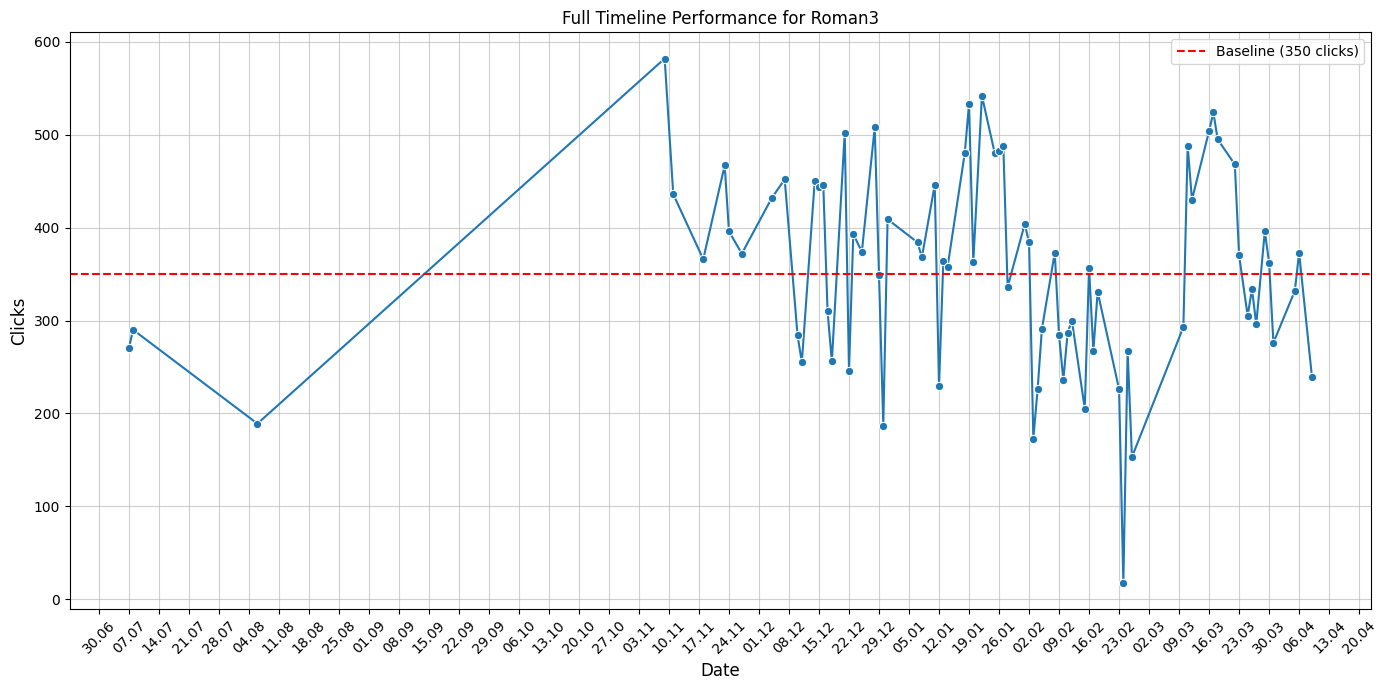

In [20]:
# --- TIMELINE PERFORMANCE VISUALIZATION ---

# Ensure the 'figures' directory exists locally before saving the plot
os.makedirs('figures', exist_ok=True)

# Filter data for name 'Roman3' from df_latest_daily_version
roman3_df = df_latest_daily_version[df_latest_daily_version['name'] == 'Roman3'].sort_values(by='date')

# Check if data exists for 'Roman3'
if not roman3_df.empty:
    plt.figure(figsize=(14, 7))
    sns.lineplot(x='date', y='clicks', data=roman3_df, marker='o')

    # --- UNIFIED GRID FORMAT ---
    # Major grid: Every 7 days (Mondays)
    plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
    # Date format: Day.Month (e.g., 01.12)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))

    # Add a horizontal baseline at 350 clicks
    plt.axhline(y=350, color='r', linestyle='--', label='Baseline (350 clicks)')

    plt.title('Full Timeline Performance for Roman3')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Clicks', fontsize=12)

    # Clean up grid lines to make them neat
    plt.grid(True, which='major', linestyle='-', alpha=0.6)
    plt.grid(True, which='minor', linestyle=':', alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.legend()

    # Save the plot locally
    output_fig_path = 'figures/fig_1.png'
    plt.savefig(output_fig_path)
    print(f"✓ Plot successfully saved to: {os.path.abspath(output_fig_path)}")
    plt.show()
else:
    print("✗ Error: No data found for 'Roman3' in the filtered DataFrame.")

### 2. Focused Performance Analysis (Dec 2025 – April 2026)


Filtered view starting from December 2025 to ensure data density and better representativeness for current performance evaluation.

Additionally, a vertical line is added at **March 22, 2026**, marking the date 'Roman3' officially joined **Golf**.

✓ Plot successfully saved to: D:\Projects\Click Count\figures\fig_2.png


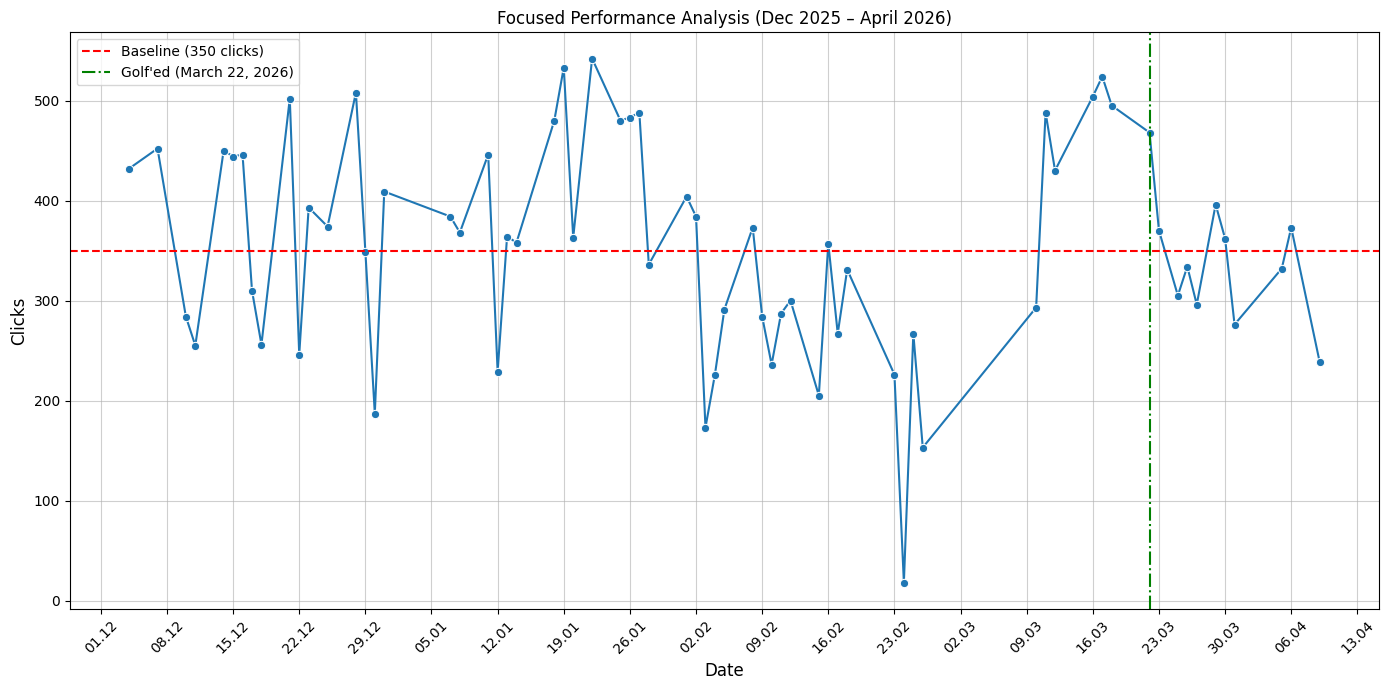

In [21]:
# --- FOCUSED PERFORMANCE ANALYSIS (DEC 2025 – APRIL 2026) ---

# Ensure the 'figures' directory exists locally before saving the plot
os.makedirs('figures', exist_ok=True)

# Filter data for name 'Roman3' from df_latest_daily_version starting from Dec 1, 2025
roman3_df = df_latest_daily_version[
    (df_latest_daily_version['name'] == 'Roman3') &
    (df_latest_daily_version['date'] >= '2025-12-01')
].sort_values(by='date')

# Check if data exists for 'Roman3'
if not roman3_df.empty:
    plt.figure(figsize=(14, 7))
    sns.lineplot(x='date', y='clicks', data=roman3_df, marker='o')

    # --- UNIFIED GRID FORMAT ---
    # Major grid: Every 7 days (Mondays)
    plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
    # Date format: Day.Month
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))

    # Add a horizontal baseline at 350 clicks
    plt.axhline(y=350, color='r', linestyle='--', label='Baseline (350 clicks)')

    # Add a vertical line for March 22, 2026
    plt.axvline(x=pd.to_datetime('2026-03-22'), color='g', linestyle='-.', label="Golf'ed (March 22, 2026)")

    plt.title('Focused Performance Analysis (Dec 2025 – April 2026)')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Clicks', fontsize=12)

    # Clean up grid lines to make them neat
    plt.grid(True, which='major', linestyle='-', alpha=0.6)
    plt.grid(True, which='minor', linestyle=':', alpha=0.3)

    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()

    # Save the plot locally
    output_fig_path = 'figures/fig_2.png'
    plt.savefig(output_fig_path)
    print(f"✓ Plot successfully saved to: {os.path.abspath(output_fig_path)}")
    plt.show()
else:
    print("✗ Error: No data found for 'Roman3' within the specified date range.")

### 3. Peer Benchmarking: 'Roman3' vs. Key Staff

Comparative analysis of 'Roman3' against selected colleagues ('DimaV', 'ArtiomB', 'Fernando') to establish relative performance levels. These employees were selected randomly for benchmarking purposes.

✓ Plot successfully saved to: D:\Projects\Click Count\figures\fig_3.png


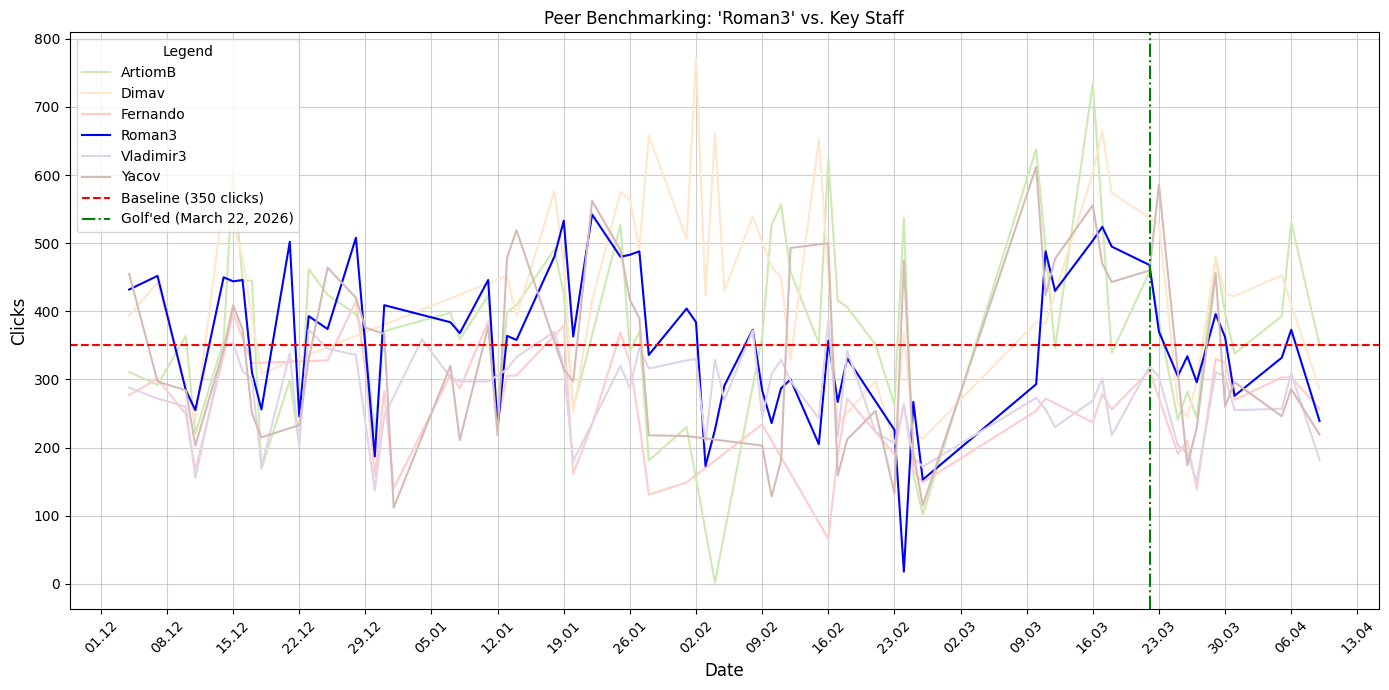

In [22]:
# --- PEER BENCHMARKING VISUALIZATION ---

# Ensure the 'figures' directory exists locally before saving the plot
os.makedirs('figures', exist_ok=True)

# Define the list of names to plot
names_to_plot = ['Roman3', 'Dimav', 'ArtiomB', 'Fernando', 'Vladimir3', 'Yacov']

# Define a custom color palette with 'Roman3' in blue
custom_palette = {
    'Roman3': 'blue',         # Rich Blue (Royal Blue)
    'Dimav': '#ffe6cc',       # Light Orange (Pale Orange)
    'ArtiomB': '#cceab2',     # Light Green (Pale Green)
    'Fernando': '#ffcccc',    # Light Red (Soft Red/Pink)
    'Vladimir3': '#e1d3e8',   # Light Purple (Pale Purple)
    'Yacov': '#d6bab5'        # Light Brown (Pale Brown)
}

# Filter data for the specified names and period from df_latest_daily_version
multi_name_df = df_latest_daily_version[
    (df_latest_daily_version['name'].isin(names_to_plot)) &
    (df_latest_daily_version['date'] >= '2025-12-01')
].sort_values(by=['name', 'date'])

# Check if there is data for any of the names
if not multi_name_df.empty:
    plt.figure(figsize=(14, 7))
    sns.lineplot(x='date', y='clicks', hue='name', data=multi_name_df, palette=custom_palette)

    # --- UNIFIED GRID FORMAT ---
    # Major grid: Every 7 days (Mondays)
    plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
    # Date format: Day.Month
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))

    # Add horizontal line at 350 clicks
    plt.axhline(y=350, color='r', linestyle='--', label='Baseline (350 clicks)')

    # Add vertical line on March 22, 2026
    plt.axvline(x=pd.to_datetime('2026-03-22'), color='g', linestyle='-.', label="Golf'ed (March 22, 2026)")

    plt.title("Peer Benchmarking: 'Roman3' vs. Key Staff")
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Clicks', fontsize=12)

    # Clean up grid lines to make them neat
    plt.grid(True, which='major', linestyle='-', alpha=0.6)
    plt.grid(True, which='minor', linestyle=':', alpha=0.3)

    plt.xticks(rotation=45)
    plt.legend(title='Legend')
    plt.tight_layout()

    # Save the plot locally
    output_fig_path = 'figures/fig_3.png'
    plt.savefig(output_fig_path)
    print(f"✓ Plot successfully saved to: {os.path.abspath(output_fig_path)}")
    plt.show()
else:
    print("✗ Error: No data found within the specified date range.")

### 4. Contextual Impact: SABON Launch & Geopolitical Events

Correlation between workload and external factors. This visualization highlights how specialized assignments (SABON) and regional instability (EPIC FURRY) influenced output.


*   **SABON:** Represents the period when **'Roman3'** was assigned to a newly launched department. Working in this department required significantly more focus, precision, and effort compared to standard operations.
*   **EPIC FURRY:** Marks the onset of active military operations in Israel and the USA against Iran. This geopolitical event had a substantial impact on overall business logistics and operations.

✓ Plot successfully saved to: D:\Projects\Click Count\figures\fig_4.png


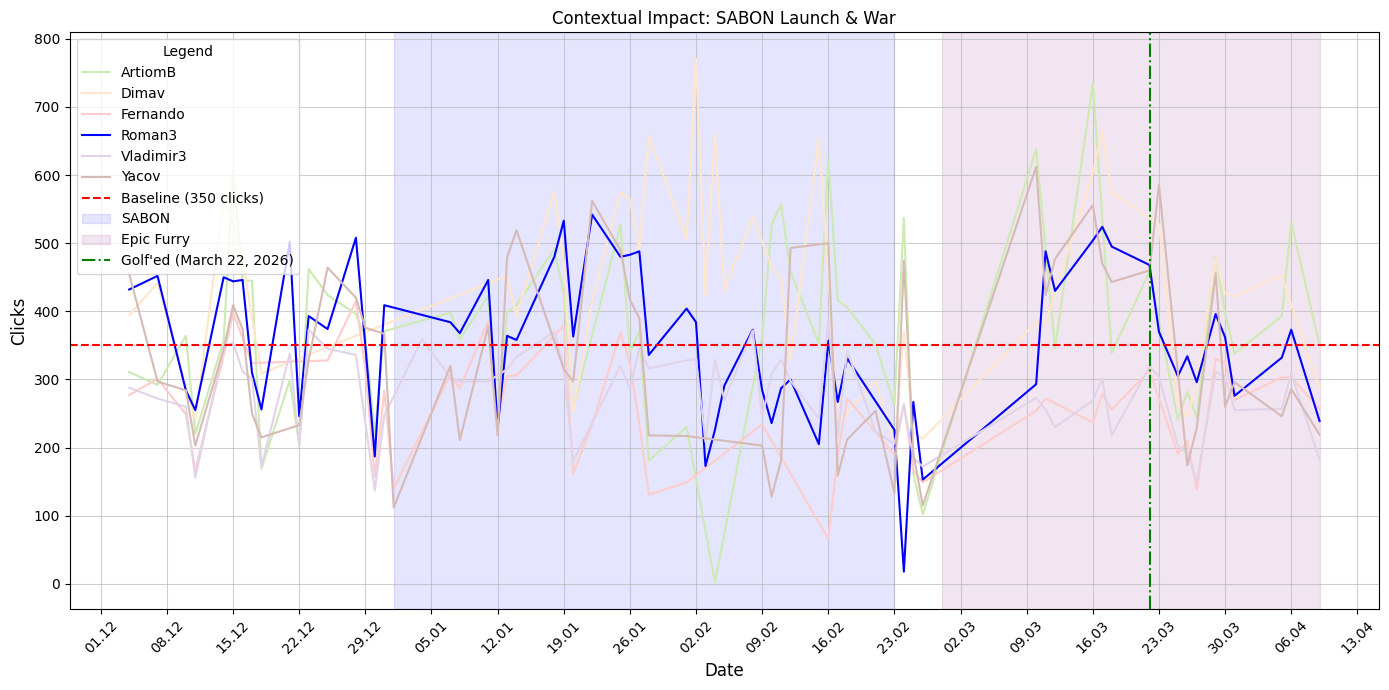

In [23]:
# --- CONTEXTUAL IMPACT VISUALIZATION (SABON & EPIC FURRY) ---

# Ensure the 'figures' directory exists locally before saving the plot
os.makedirs('figures', exist_ok=True)

# Filter data for the specified names and period from df_latest_daily_version
multi_name_df = df_latest_daily_version[
    (df_latest_daily_version['name'].isin(names_to_plot)) &
    (df_latest_daily_version['date'] >= '2025-12-01')
].sort_values(by=['name', 'date'])

# Check if there is data for any of the names
if not multi_name_df.empty:
    plt.figure(figsize=(14, 7))
    sns.lineplot(x='date', y='clicks', hue='name', data=multi_name_df, palette=custom_palette)

    # --- UNIFIED GRID FORMAT ---
    # Major grid: Every 7 days (Mondays)
    plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
    # Date format: Day.Month
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))

    # Add horizontal line at 350 clicks
    plt.axhline(y=350, color='r', linestyle='--', label='Baseline (350 clicks)')

    # Add two periods to the graph
    # SABON period: January 1st to February 23rd, 2026
    plt.axvspan(pd.to_datetime('2026-01-01'), pd.to_datetime('2026-02-23'), color='blue', alpha=0.1, label='SABON')
    # Epic Furry period: February 28th, 2026 to the latest date in the data
    plt.axvspan(pd.to_datetime('2026-02-28'), multi_name_df['date'].max(), color='purple', alpha=0.1, label='Epic Furry')

    # Add vertical line on March 22, 2026
    plt.axvline(x=pd.to_datetime('2026-03-22'), color='g', linestyle='-.', label="Golf'ed (March 22, 2026)")

    plt.title("Contextual Impact: SABON Launch & War")
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Clicks', fontsize=12)

    # Clean up grid lines to make them neat
    plt.grid(True, which='major', linestyle='-', alpha=0.6)
    plt.grid(True, which='minor', linestyle=':', alpha=0.3)

    plt.xticks(rotation=45)
    plt.legend(title='Legend')
    plt.tight_layout()

    # Save the plot locally
    output_fig_path = 'figures/fig_4.png'
    plt.savefig(output_fig_path)
    print(f"✓ Plot successfully saved to: {os.path.abspath(output_fig_path)}")
    plt.show()
else:
    print("✗ Error: No data found for the specified names within the selected date range.")

### 5. Comparative Efficiency: 'Roman3' vs. New Onboarders (Thai Staff)

Description: Benchmarking 'Roman3' against the newly joined staff from Thailand to evaluate the efficiency of an experienced employee versus new arrivals.



✓ Plot successfully saved to: D:\Projects\Click Count\figures\fig_5.png


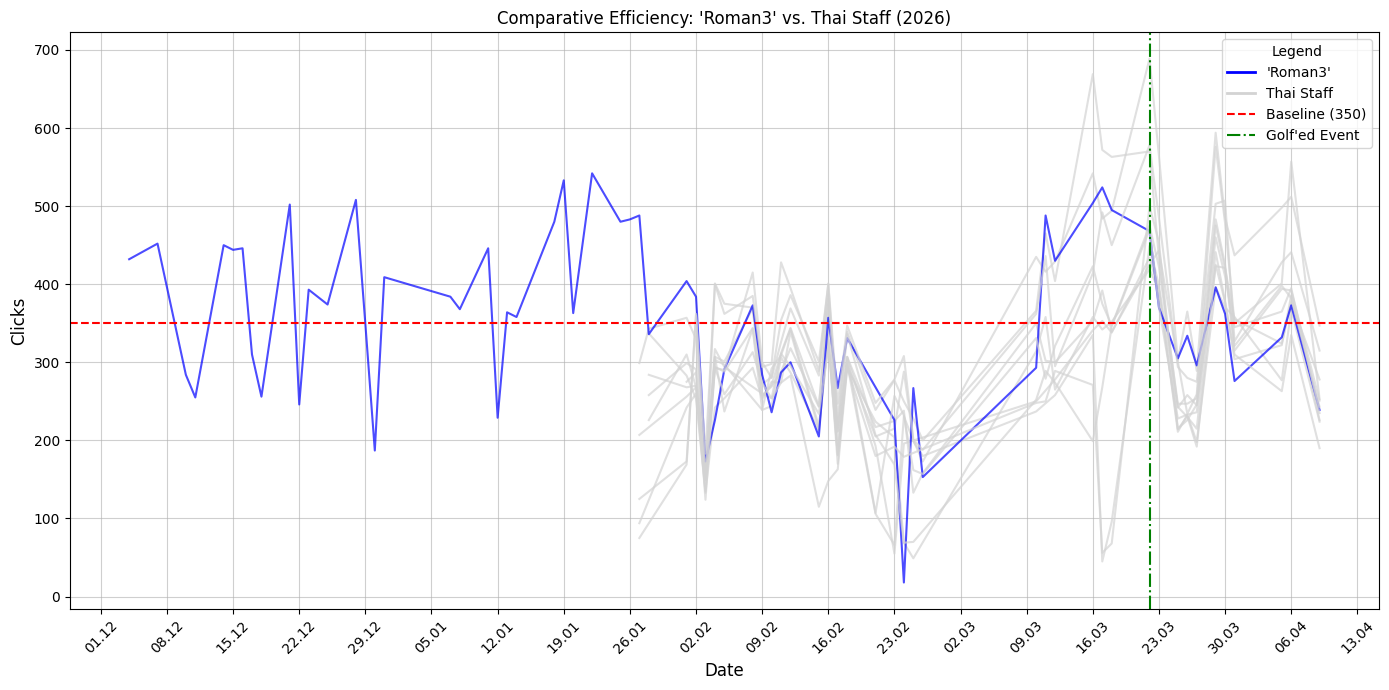

In [24]:
# --- COMPARATIVE EFFICIENCY VISUALIZATION (ROMAN3 VS THAI STAFF) ---

# Ensure the 'figures' directory exists locally before saving the plot
os.makedirs('figures', exist_ok=True)

# 1. Automatically detect Thai staff names (all uppercase), excluding SAVA3
thai_staff_names = [name for name in df_latest_daily_version['name'].unique()
                    if isinstance(name, str) and name.isupper() and name != 'SAVA3']

# 2. Form the list for filtering: only Roman3 and Thai staff
combined_names_to_plot = list(set(thai_staff_names + ['Roman3']))

# 3. Filter data for the 2026 period
multi_name_df_thai_caps = df_latest_daily_version[
    (df_latest_daily_version['name'].isin(combined_names_to_plot)) &
    (df_latest_daily_version['date'] >= '2025-12-01')
].sort_values(by=['name', 'date'])

if not multi_name_df_thai_caps.empty:
    plt.figure(figsize=(14, 7))

    # Color scheme: Roman3 is blue, others (Thai staff) are light grey
    custom_palette_mapping = {name: 'lightgrey' for name in multi_name_df_thai_caps['name'].unique()}
    if 'Roman3' in custom_palette_mapping:
        custom_palette_mapping['Roman3'] = 'blue'

    sns.lineplot(x='date', y='clicks', hue='name', data=multi_name_df_thai_caps,
                palette=custom_palette_mapping, alpha=0.7)

    # --- UNIFIED GRID FORMAT ---
    plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))

    # Baseline and Event lines
    plt.axhline(y=350, color='r', linestyle='--', label='Baseline (350 clicks)')
    plt.axvline(x=pd.to_datetime('2026-03-22'), color='g', linestyle='-.', label="Golf'ed (March 22, 2026)")

    plt.title("Comparative Efficiency: 'Roman3' vs. Thai Staff (2026)")
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Clicks', fontsize=12)

    # Grid styling
    plt.grid(True, which='major', linestyle='-', alpha=0.6)
    plt.grid(True, which='minor', linestyle=':', alpha=0.3)
    plt.xticks(rotation=45)

    # --- Manual Legend Creation ---
    legend_elements = []

    # Roman3
    if 'Roman3' in multi_name_df_thai_caps['name'].unique():
        legend_elements.append(mlines.Line2D([0], [0], color='blue', lw=2,  label="'Roman3'"))

    # Thai Staff Group
    legend_elements.append(mlines.Line2D([0], [0], color='lightgrey', lw=2,  label='Thai Staff'))

    # Technical Lines
    legend_elements.append(mlines.Line2D([0], [0], color='r', linestyle='--', label='Baseline (350)'))
    legend_elements.append(mlines.Line2D([0], [0], color='g', linestyle='-.', label="Golf'ed Event"))

    plt.legend(handles=legend_elements, title='Legend')
    plt.tight_layout()

    # Save the plot locally
    output_fig_path = 'figures/fig_5.png'
    plt.savefig(output_fig_path)
    print(f"✓ Plot successfully saved to: {os.path.abspath(output_fig_path)}")
    plt.show()
else:
    print("✗ Error: No data found for the analysis.")

### 6. Overall Performance Distribution & Average Ranking

A ranking of all employees by their average click count. 'Roman3' is highlighted to show his standing relative to the company-wide 350-click baseline.

✓ Plot successfully saved to: D:\Projects\Click Count\figures\fig_6.png


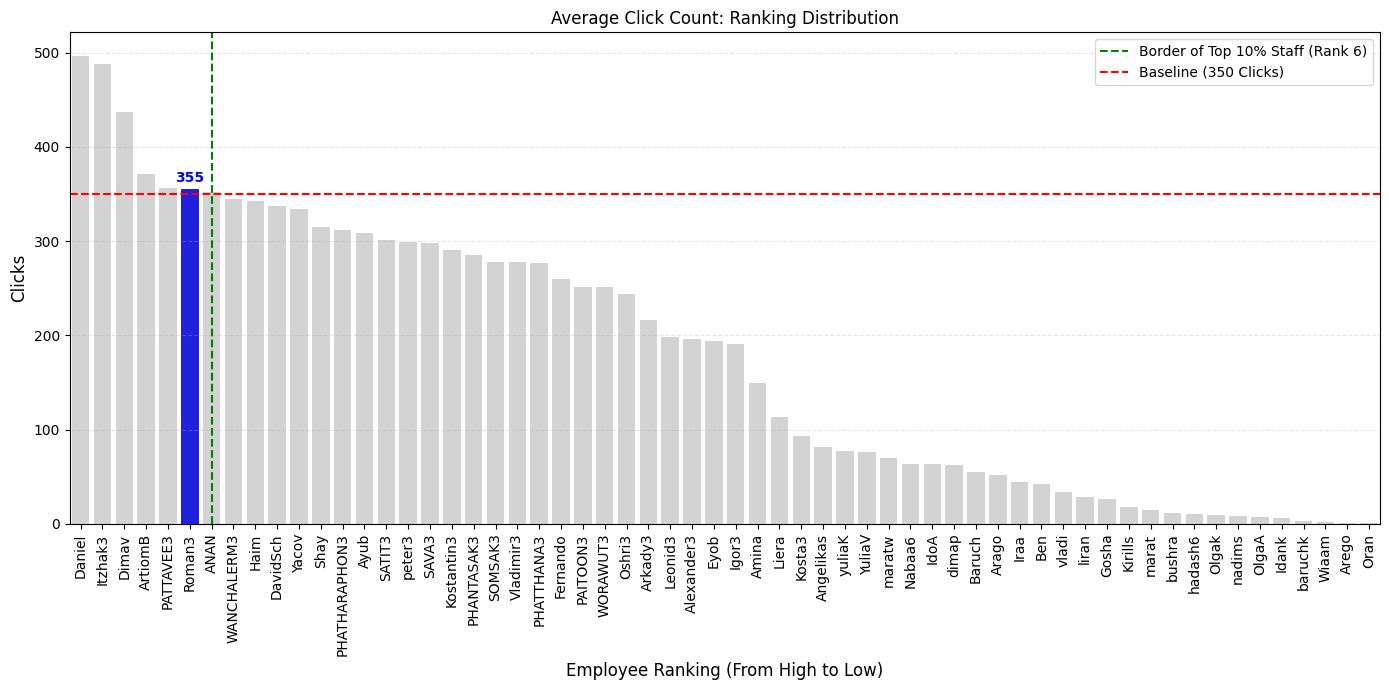

In [25]:
# --- OVERALL PERFORMANCE DISTRIBUTION & RANKING ---

# Ensure the 'figures' directory exists locally before saving the plot
os.makedirs('figures', exist_ok=True)

# Filter data starting from December 2025
df_2026 = df_latest_daily_version[df_latest_daily_version['date'] >= '2025-12-01'].copy()

# Group by name and calculate the average click count
average_clicks_per_name = df_2026.groupby('name')['clicks'].mean().reset_index()

# Sort from highest to lowest (ranking distribution)
average_clicks_per_name = average_clicks_per_name.sort_values(by='clicks', ascending=False).reset_index(drop=True)

# --- PERCENTILE CALCULATION BY STAFF COUNT ---
total_staff = len(average_clicks_per_name)
top_10_percent_rank = int(total_staff * 0.10)

plt.figure(figsize=(14, 7))

# Colors: 'Roman3' is blue, everyone else is lightgrey
colors = ['blue' if name == 'Roman3' else 'lightgrey' for name in average_clicks_per_name['name']]

sns.barplot(x='name', y='clicks', data=average_clicks_per_name, hue='name', palette=colors, legend=False)

# Vertical line separating top 10% performers
plt.axvline(x=top_10_percent_rank, color='green', linestyle='--', label=f'Border of Top 10% Staff (Rank {top_10_percent_rank})')

# Horizontal Baseline line
plt.axhline(y=350, color='r', linestyle='--', label='Baseline (350 Clicks)')

plt.title('Average Click Count: Ranking Distribution')
plt.xlabel('Employee Ranking (From High to Low)', fontsize=12)
plt.ylabel('Clicks', fontsize=12)
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Value label for Roman3 (with safety check)
if 'Roman3' in average_clicks_per_name['name'].values:
    roman3_avg_clicks = average_clicks_per_name[average_clicks_per_name['name'] == 'Roman3']['clicks'].iloc[0]
    x_roman3 = list(average_clicks_per_name['name']).index('Roman3')
    plt.text(x_roman3, roman3_avg_clicks + 5, f'{roman3_avg_clicks:.0f}', ha='center', va='bottom', color='blue', fontweight='bold')

plt.legend()
plt.tight_layout()

# Save the plot locally
output_fig_path = 'figures/fig_6.png'
plt.savefig(output_fig_path)
print(f"✓ Plot successfully saved to: {os.path.abspath(output_fig_path)}")
plt.show()

### 7. 'Roman3' 7-Day Rolling Average vs. Company Average

This trend analysis compares 'Roman3's 7-day rolling average against the company-wide average to highlight long-term performance trends. The graph includes shaded regions for two major operational milestones: the launch of the new SABON department (blue) and a forced operational pause (purple). This overlay provides direct context on how workload spikes and external disruptions impacted both individual and team productivity.

✓ Plot successfully saved to: D:\Projects\Click Count\figures\fig_7.png


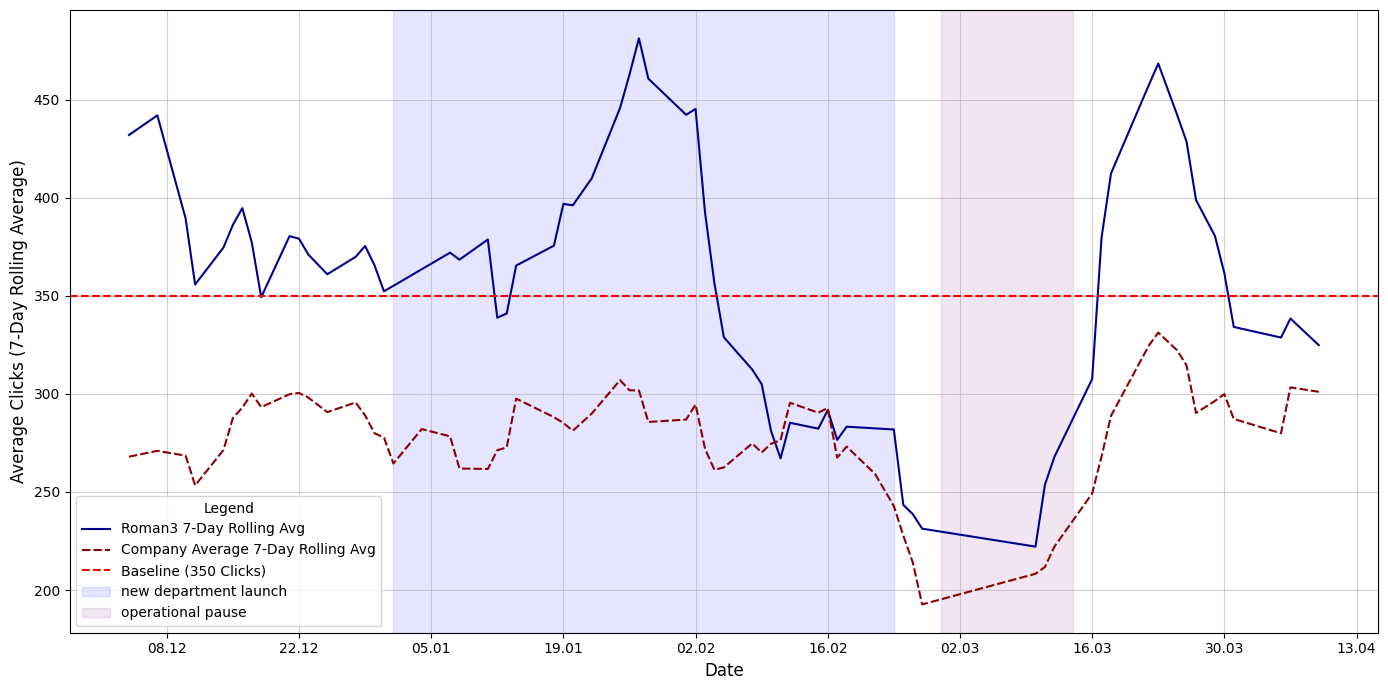

In [26]:
# --- ROMAN3 7-DAY ROLLING AVERAGE VS COMPANY AVERAGE ---

# Ensure the 'figures' directory exists locally before saving the plot
os.makedirs('figures', exist_ok=True)

# Filter data for Roman3 starting from December 2025
roman3_2026_df = df_latest_daily_version[
    (df_latest_daily_version['name'] == 'Roman3') &
    (df_latest_daily_version['date'] >= '2025-12-01')
].copy()

# Group by date and calculate the average click count for Roman3
roman3_average_clicks_per_day = roman3_2026_df.groupby('date')['clicks'].mean().reset_index()
# Calculate 7-day rolling average for Roman3
roman3_average_clicks_per_day['rolling_avg'] = roman3_average_clicks_per_day['clicks'].rolling(window=7, min_periods=1).mean()
roman3_average_clicks_per_day_ra = roman3_average_clicks_per_day.copy()
roman3_average_clicks_per_day_ra['clicks'] = roman3_average_clicks_per_day_ra['rolling_avg']
roman3_average_clicks_per_day_ra['type'] = 'Roman3 7-Day Rolling Avg'

# Extract data starting from December 2025 for the overall average
df_2026_daily_avg = df_latest_daily_version[df_latest_daily_version['date'] >= '2025-12-01'].copy()

# Group by date and calculate the company-wide average click count
overall_average_clicks_per_day = df_2026_daily_avg.groupby('date')['clicks'].mean().reset_index()
# Calculate 7-day rolling average for Company Average
overall_average_clicks_per_day['rolling_avg'] = overall_average_clicks_per_day['clicks'].rolling(window=7, min_periods=1).mean()
overall_average_clicks_per_day_ra = overall_average_clicks_per_day.copy()
overall_average_clicks_per_day_ra['clicks'] = overall_average_clicks_per_day_ra['rolling_avg']
overall_average_clicks_per_day_ra['type'] = 'Company Average 7-Day Rolling Avg'

# Combine only rolling average data for plotting
comparison_daily_df = pd.concat([
    roman3_average_clicks_per_day_ra[['date', 'clicks', 'type']],
    overall_average_clicks_per_day_ra[['date', 'clicks', 'type']]
])

plt.figure(figsize=(14, 7))
sns.lineplot(x='date', y='clicks', hue='type', data=comparison_daily_df,
             palette={'Roman3 7-Day Rolling Avg': 'darkblue', 'Company Average 7-Day Rolling Avg': 'darkred'},
             style='type')

# --- UNIFIED GRID FORMAT ---
# Major grid: Every 14 days (Mondays, interval=2) for cleaner presentation
plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))

# Horizontal Baseline line
plt.axhline(y=350, color='r', linestyle='--', label='Baseline (350 Clicks)')

# Add two operational milestones to the graph
# SABON period: January 1st to February 23rd, 2026
plt.axvspan(pd.to_datetime('2026-01-01'), pd.to_datetime('2026-02-23'), color='blue', alpha=0.1, label='new department launch')
# Epic Furry period: February 28th, 2026 to March 14th, 2026
plt.axvspan(pd.to_datetime('2026-02-28'), pd.to_datetime('2026-03-14'), color='purple', alpha=0.1, label='operational pause')

#plt.title("'Roman3' 7-Day Rolling Average vs. Company Average")
plt.xlabel('Date', fontsize=12)
plt.ylabel('Average Clicks (7-Day Rolling Average)', fontsize=12)

# Standardized grid styling
plt.grid(True, which='major', linestyle='-', alpha=0.6)
plt.grid(True, which='minor', linestyle=':', alpha=0.3)

plt.xticks(rotation=0)
plt.legend(title='Legend')
plt.tight_layout()

# Save the plot locally
output_fig_path = 'figures/fig_7.png'
plt.savefig(output_fig_path)
print(f"✓ Plot successfully saved to: {os.path.abspath(output_fig_path)}")
plt.show()

*'Roman3' 7-Day Rolling Average vs. Company Average*

### 8. Click Distribution for Top 5 Most Active Employees

This visualization shows the distribution of daily clicks for the top 5 employees, giving insights into their consistency and range of performance.

✓ Plot successfully saved to: D:\Projects\Click Count\figures\fig_8.png


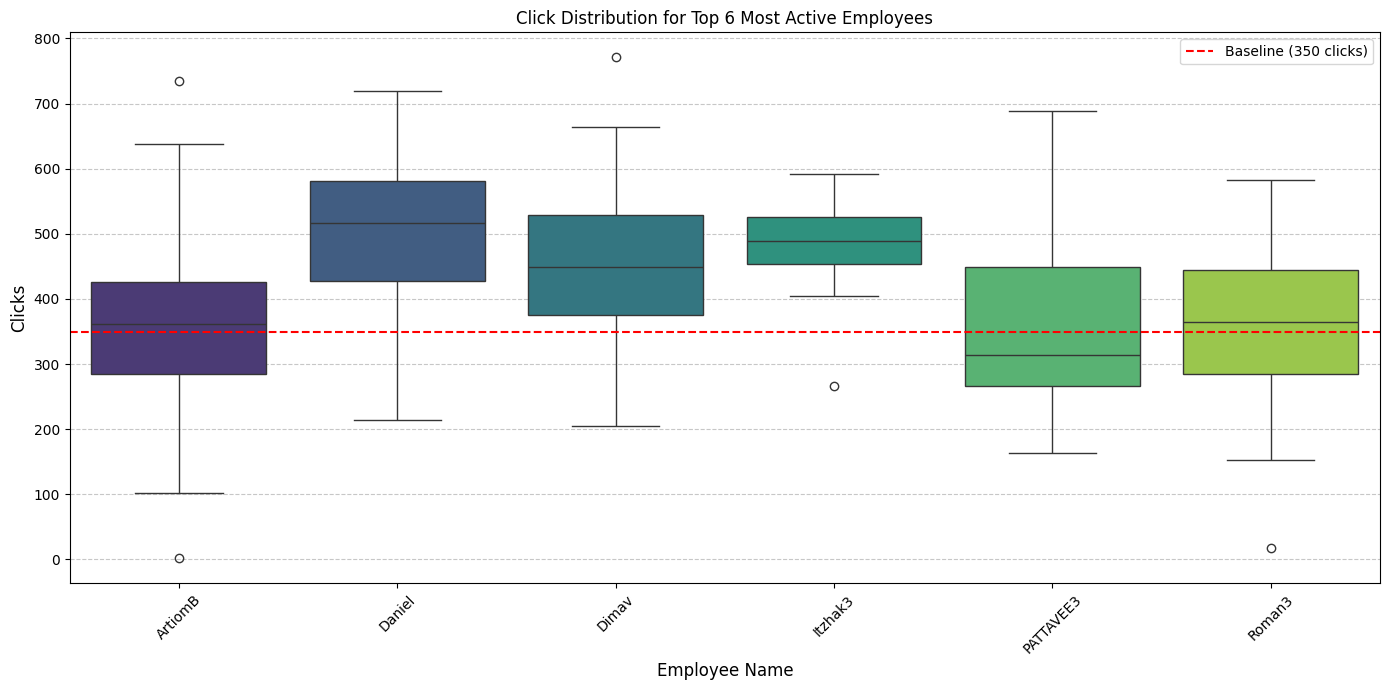

In [27]:
# --- CLICK DISTRIBUTION VISUALIZATION (BOXPLOT) ---

# Ensure the 'figures' directory exists locally before saving the plot
os.makedirs('figures', exist_ok=True)

# Get the top 6 most active employees based on average clicks
top_6_employees = average_clicks_per_name.head(6)['name'].tolist()

# Filter the df_latest_daily_version for these top 6 employees
top_6_df = df_latest_daily_version[
    df_latest_daily_version['name'].isin(top_6_employees)
].copy()

plt.figure(figsize=(14, 7))
# Explicitly passing hue to avoid future warning and setting legend to False
sns.boxplot(x='name', y='clicks', data=top_6_df, hue='name', palette='viridis', legend=False)

# Horizontal Baseline line
plt.axhline(y=350, color='r', linestyle='--', label='Baseline (350 clicks)')

plt.title('Click Distribution for Top 6 Most Active Employees')
plt.xlabel('Employee Name',fontsize=12)
plt.ylabel('Clicks', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()

# Save the plot locally
output_fig_path = 'figures/fig_8.png'
plt.savefig(output_fig_path)
print(f"✓ Plot successfully saved to: {os.path.abspath(output_fig_path)}")
plt.show()